# Vigor Dynamics Along the Threat Imminence Continuum

Three questions:
1. **Pre-encounter:** Do people press harder when threat is higher? (within cookie type)
2. **Encounter:** What happens to pressing the moment the predator appears?
3. **Terminal:** What happens to pressing as the predator approaches strike?

**Metric:** Normalized press rate = median(1/IPI) / calibrationMax. Scale 0 to ~1.5. Same physical scale regardless of cookie type. Cookie type controlled by running analyses separately for heavy and light, and by including cookie as a covariate.

**Resolution:** 200ms bins from raw keypress timestamps (5Hz native resolution), 3-point moving average (600ms) for display.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, ast
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, pearsonr, ttest_1samp
from pathlib import Path
import os

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.right': False, 'axes.spines.top': False})

# Find repo root (walk up until we find CLAUDE.md or .git)
_nb_dir = Path(os.getcwd())
REPO_ROOT = _nb_dir
for _ in range(5):
    if (REPO_ROOT / '.git').exists() or (REPO_ROOT / 'CLAUDE.md').exists():
        break
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260320_191950"
RESULTS_DIR = REPO_ROOT / "results/stats"
EXCLUDE = [154, 197, 208]
BIN = 0.2  # 200ms
SMOOTH = 3  # 3-point moving average

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()}")

beh = pd.read_csv(DATA_DIR / "behavior_rich.csv", low_memory=False)
beh = beh[~beh['subj'].isin(EXCLUDE)].copy()
beh['T_round'] = beh['threat'].round(1)
beh['is_heavy'] = (beh['trialCookie_weight'] == 3.0).astype(int)
beh['actual_req'] = np.where(beh['is_heavy'] == 1, 0.9, 0.4)
beh['enc_t'] = pd.to_numeric(beh['encounterTime'], errors='coerce')
beh['strike_t'] = pd.to_numeric(beh['strike_time'], errors='coerce')
beh['is_attack'] = beh['isAttackTrial'].astype(int)

print(f"Loaded {len(beh)} trials, {beh['subj'].nunique()} subjects")

Repo root: /Users/nokada/Documents/CALTECH/EffortForagingUnderThreat
Data dir exists: True
Loaded 23490 trials, 290 subjects


## Compute timecourse data from raw keypresses

For each trial, compute normalized press rate in 200ms bins across three timeframes:
- **Onset-aligned** (time from trial start): shows the ramp-up and pre-encounter threat modulation
- **Encounter-aligned** (time from encounterTime): shows the encounter response
- **Strike-aligned** (time from strike_time, attack trials only): shows terminal behavior

In [2]:
%%time

WIN_ONSET = np.arange(0, 6.0, BIN)
WIN_ENC = np.arange(-2.0, 5.0, BIN)
WIN_STRIKE = np.arange(-5.0, 1.0, BIN)

onset_recs, enc_recs, strike_recs = [], [], []

for _, row in beh.iterrows():
    try:
        pt = np.array(ast.literal_eval(str(row['alignedEffortRate'])), dtype=float)
        if len(pt) < 5: continue
        cal = row['calibrationMax']; enc = row['enc_t']; strike = row['strike_t']
        if cal <= 0 or pd.isna(enc): continue

        ipis = np.diff(pt)
        midpoints = (pt[:-1] + pt[1:]) / 2
        rates = np.where(ipis > 0.01, (1.0 / ipis) / cal, np.nan)

        base = dict(subj=row['subj'], T_round=row['T_round'],
                    cookie=row['is_heavy'], is_attack=row['is_attack'])

        # Onset-aligned
        for t0 in WIN_ONSET:
            mask = (midpoints >= t0) & (midpoints < t0 + BIN)
            v = rates[mask]; v = v[~np.isnan(v)]
            if len(v) >= 1:
                onset_recs.append({**base, 't_bin': round(t0 + BIN/2, 2), 'rate': np.median(v)})

        # Encounter-aligned
        enc_mid = midpoints - enc
        for t0 in WIN_ENC:
            mask = (enc_mid >= t0) & (enc_mid < t0 + BIN)
            v = rates[mask]; v = v[~np.isnan(v)]
            if len(v) >= 1:
                enc_recs.append({**base, 't_bin': round(t0 + BIN/2, 2), 'rate': np.median(v)})

        # Strike-aligned (attack only)
        if row['is_attack'] == 1 and not pd.isna(strike) and strike > enc + 1:
            strike_mid = midpoints - strike
            for t0 in WIN_STRIKE:
                mask = (strike_mid >= t0) & (strike_mid < t0 + BIN)
                v = rates[mask]; v = v[~np.isnan(v)]
                if len(v) >= 1:
                    strike_recs.append({**base, 't_bin': round(t0 + BIN/2, 2), 'rate': np.median(v)})
    except: pass

onset_df = pd.DataFrame(onset_recs)
enc_df = pd.DataFrame(enc_recs)
strike_df = pd.DataFrame(strike_recs)

print(f"Onset: {len(onset_df):,} records")
print(f"Encounter: {len(enc_df):,} records")
print(f"Strike: {len(strike_df):,} records")

Onset: 435,635 records
Encounter: 543,355 records
Strike: 233,456 records
CPU times: user 19.9 s, sys: 321 ms, total: 20.2 s
Wall time: 20.7 s


## 1. Pre-encounter: Threat modulates vigor

Onset-aligned normalized press rate, cookie-type controlled. At each time bin, the cookie-type mean is subtracted and the grand mean added back — this removes the heavy/light level difference while preserving the threat signal on a single combined plot.

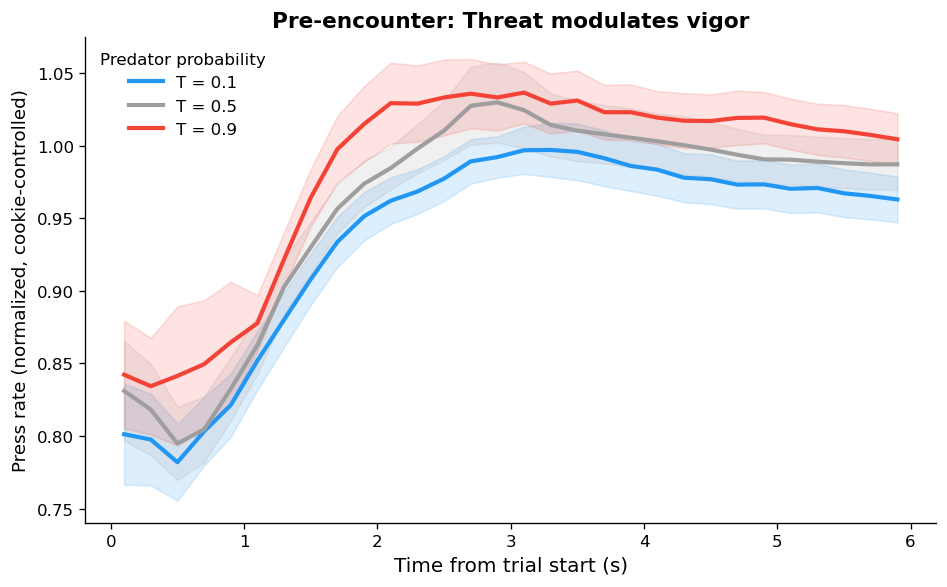


Paired t-test (T=0.9 vs T=0.1, within cookie type):
  Heavy: Δ=+0.0391, t=7.40, p=1.48e-12, d=+0.435
  Light: Δ=+0.0558, t=13.53, p=1.19e-32, d=+0.796


In [3]:
def smooth(s, w=SMOOTH):
    return s.rolling(w, center=True, min_periods=1).mean()

def cookie_center(df, val_col='rate'):
    """Remove cookie-type mean at each time bin, add back grand mean."""
    cookie_means = df.groupby(['cookie', 't_bin'])[val_col].transform('mean')
    grand_means = df.groupby('t_bin')[val_col].transform('mean')
    df[val_col + '_cc'] = df[val_col] - cookie_means + grand_means
    return df

# Per-subject first, then average
def agg_timecourse(df, group_cols, val_col='rate', min_count=100):
    subj = df.groupby(['subj'] + group_cols + ['t_bin'])[val_col].mean().reset_index()
    agg = subj.groupby(group_cols + ['t_bin'])[val_col].agg(['mean', 'sem', 'count']).reset_index()
    return agg[agg['count'] >= 30]

C = {0.1: '#2196F3', 0.5: '#9E9E9E', 0.9: '#F44336'}

# Cookie-center the onset data
onset_df = cookie_center(onset_df)

fig, ax = plt.subplots(figsize=(8, 5))

ts = agg_timecourse(onset_df, ['T_round'], val_col='rate_cc')

for T in [0.1, 0.5, 0.9]:
    d = ts[ts['T_round'] == T].sort_values('t_bin')
    m = smooth(d['mean']); s = smooth(d['sem'])
    ax.plot(d['t_bin'], m, color=C[T], lw=2.5, label=f'T = {T}')
    ax.fill_between(d['t_bin'], m - s, m + s, color=C[T], alpha=0.15)

ax.set_xlabel('Time from trial start (s)', fontsize=12)
ax.set_ylabel('Press rate (normalized, cookie-controlled)', fontsize=11)
ax.set_title('Pre-encounter: Threat modulates vigor', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, frameon=False, title='Predator probability')
plt.tight_layout()
plt.show()

# Stats: paired t-test T=0.9 vs T=0.1 for trial-level mean rate
print("\nPaired t-test (T=0.9 vs T=0.1, within cookie type):")
vigor_metrics_path = RESULTS_DIR / "vigor_analysis/vigor_metrics.csv"
if vigor_metrics_path.exists():
    metrics = pd.read_csv(vigor_metrics_path)
    full = metrics[metrics['epoch'] == 'full']
    for ck, label in [(1, 'Heavy'), (0, 'Light')]:
        sub = full[full['cookie'] == ck]
        lo = sub[sub['T_round'] == 0.1].groupby('subj')['norm_rate'].mean()
        hi = sub[sub['T_round'] == 0.9].groupby('subj')['norm_rate'].mean()
        shared = sorted(set(lo.index) & set(hi.index))
        diff = hi.loc[shared].values - lo.loc[shared].values
        t, p = ttest_rel(hi.loc[shared], lo.loc[shared])
        d = diff.mean() / diff.std()
        print(f"  {label}: Δ={diff.mean():+.4f}, t={t:.2f}, p={p:.2e}, d={d:+.3f}")
else:
    print("  (Run scripts/vigor_pipeline/compute_metrics.py first)")

## 2. Encounter: The moment threat becomes real

Two plots:
- **Left:** Encounter-aligned press rate by threat level (cookie-controlled). Shows whether the encounter response differs by stated threat.
- **Right:** Attack minus non-attack difference (per-subject, then averaged). Isolates the encounter effect — what the predator's appearance adds above baseline trial dynamics.

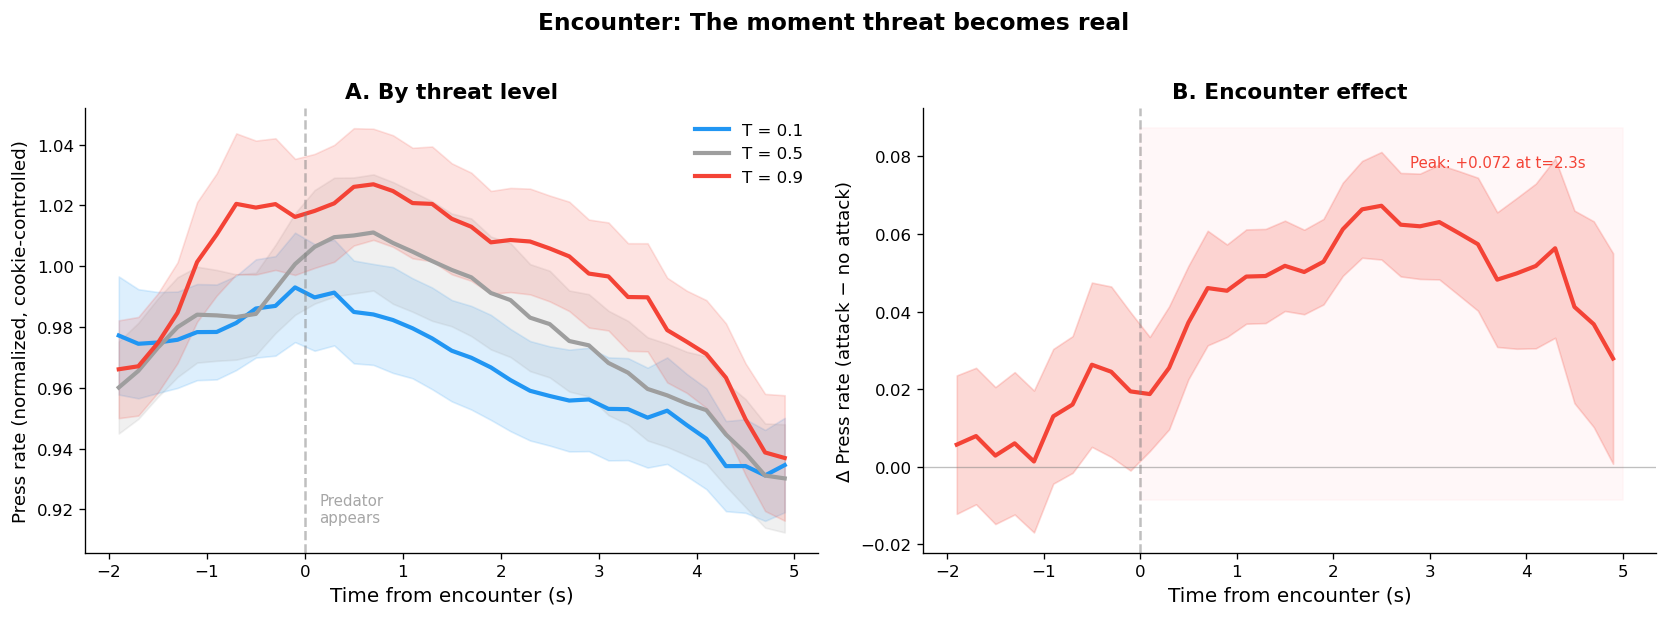


Encounter spike (attack - non-attack, normalized rate, cookie-controlled):
  Mean spike: +0.0365, t=9.59, p=4.43e-19, d=+0.563
  83% of subjects show positive spike
  T=0.1: spike=+0.0495
  T=0.5: spike=+0.0377
  T=0.9: spike=+0.0359


In [4]:
# Cookie-center the encounter data
enc_df = cookie_center(enc_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Encounter-aligned by threat (cookie-controlled, combined)
ax = axes[0]
ts = agg_timecourse(enc_df, ['T_round'], val_col='rate_cc')
for T in [0.1, 0.5, 0.9]:
    d = ts[ts['T_round'] == T].sort_values('t_bin')
    m = smooth(d['mean']); s = smooth(d['sem'])
    ax.plot(d['t_bin'], m, color=C[T], lw=2.5, label=f'T = {T}')
    ax.fill_between(d['t_bin'], m - s, m + s, color=C[T], alpha=0.15)
ax.axvline(0, color='gray', ls='--', lw=1.5, alpha=0.5)
ax.set_xlabel('Time from encounter (s)', fontsize=12)
ax.set_ylabel('Press rate (normalized, cookie-controlled)', fontsize=11)
ax.set_title('A. By threat level', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.annotate('Predator\nappears', xy=(0.15, ax.get_ylim()[0] + 0.01) if ax.get_ylim()[0] else (0.15, 0.8),
            fontsize=9, color='gray', alpha=0.7)

# Panel B: Attack - no-attack difference (per-subject, cookie-controlled)
ax = axes[1]
subj_ts = enc_df.groupby(['subj', 'is_attack', 't_bin'])['rate_cc'].mean().reset_index()
att = subj_ts[subj_ts['is_attack'] == 1].rename(columns={'rate_cc': 'att'}).drop(columns='is_attack')
non = subj_ts[subj_ts['is_attack'] == 0].rename(columns={'rate_cc': 'non'}).drop(columns='is_attack')
diff = att.merge(non, on=['subj', 't_bin'])
diff['effect'] = diff['att'] - diff['non']
panel_b = diff.groupby('t_bin')['effect'].agg(['mean', 'sem']).reset_index()

m = smooth(panel_b['mean']); s = smooth(panel_b['sem'])
ax.fill_between([0, 5], m.min() - 0.01, m.max() + 0.02, color='#FFEBEE', alpha=0.4, zorder=0)
ax.plot(panel_b['t_bin'], m, color='#F44336', lw=2.5)
ax.fill_between(panel_b['t_bin'], m - 1.96*s, m + 1.96*s, color='#F44336', alpha=0.2)
ax.axhline(0, color='gray', ls='-', lw=0.8, alpha=0.5)
ax.axvline(0, color='gray', ls='--', lw=1.5, alpha=0.5)
ax.set_xlabel('Time from encounter (s)', fontsize=12)
ax.set_ylabel('Δ Press rate (attack − no attack)', fontsize=11)
ax.set_title('B. Encounter effect', fontweight='bold', fontsize=13)

peak = panel_b.loc[panel_b['mean'].idxmax()]
ax.annotate(f'Peak: +{peak["mean"]:.3f} at t={peak["t_bin"]:.1f}s',
            xy=(peak['t_bin'], peak['mean']), xytext=(peak['t_bin']+0.5, peak['mean']+0.005),
            fontsize=9, color='#F44336')

plt.suptitle('Encounter: The moment threat becomes real', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Stats
print(f"\nEncounter spike (attack - non-attack, normalized rate, cookie-controlled):")
if vigor_metrics_path.exists():
    sub_atk = metrics[metrics['epoch']=='reactive']
    s_a = sub_atk[sub_atk['is_attack']==1].groupby('subj')['norm_rate'].mean()
    s_n = sub_atk[sub_atk['is_attack']==0].groupby('subj')['norm_rate'].mean()
    shared = sorted(set(s_a.index) & set(s_n.index))
    spike = s_a.loc[shared] - s_n.loc[shared]
    t, p = ttest_1samp(spike, 0)
    d = spike.mean() / spike.std()
    print(f"  Mean spike: {spike.mean():+.4f}, t={t:.2f}, p={p:.2e}, d={d:+.3f}")
    print(f"  {(spike>0).mean()*100:.0f}% of subjects show positive spike")
    for T in [0.1, 0.5, 0.9]:
        sa = sub_atk[(sub_atk['is_attack']==1)&(sub_atk['T_round']==T)].groupby('subj')['norm_rate'].mean()
        sn = sub_atk[(sub_atk['is_attack']==0)&(sub_atk['T_round']==T)].groupby('subj')['norm_rate'].mean()
        sh = sorted(set(sa.index)&set(sn.index))
        sp = sa.loc[sh] - sn.loc[sh]
        print(f"  T={T}: spike={sp.mean():+.4f}")

## 3. Terminal: What happens as the predator approaches

Strike-aligned timecourse (attack trials only), cookie-controlled. t=0 is the moment the predator strikes. Shows whether pressing changes as the predator closes in, and whether threat level matters in the terminal phase.

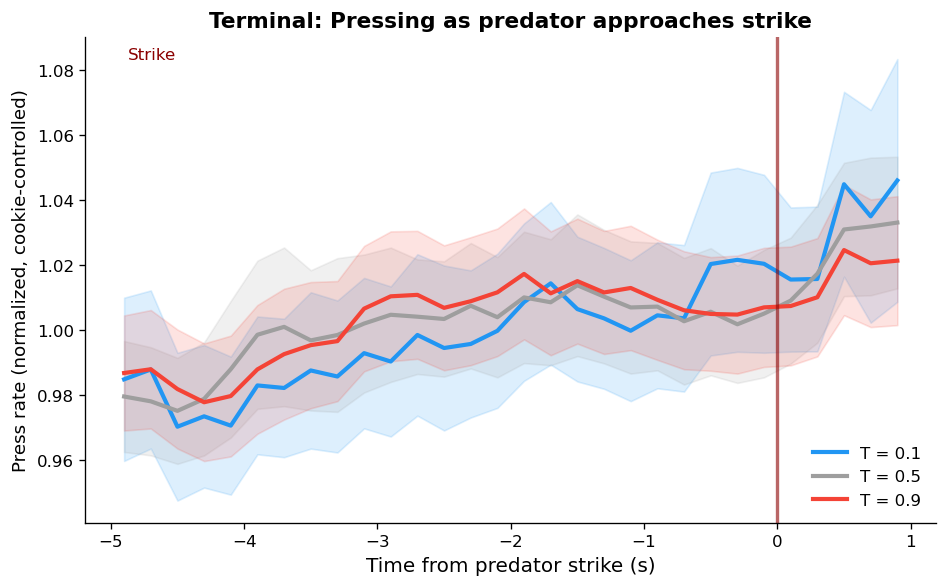


Terminal vigor by threat (within cookie type, paired t-test):
  Heavy: Δ=-0.0070, t=-0.83, p=4.08e-01, d=-0.051
  Light: Δ=+nan, t=nan, p=nan, d=+nan


In [5]:
# Cookie-center the strike data
strike_df = cookie_center(strike_df)

fig, ax = plt.subplots(figsize=(8, 5))

ts = agg_timecourse(strike_df, ['T_round'], val_col='rate_cc')
for T in [0.1, 0.5, 0.9]:
    d = ts[ts['T_round'] == T].sort_values('t_bin')
    if len(d) < 3: continue
    m = smooth(d['mean']); s = smooth(d['sem'])
    ax.plot(d['t_bin'], m, color=C[T], lw=2.5, label=f'T = {T}')
    ax.fill_between(d['t_bin'], m - s, m + s, color=C[T], alpha=0.15)

ax.axvline(0, color='darkred', ls='-', lw=2, alpha=0.6)
ax.set_xlabel('Time from predator strike (s)', fontsize=12)
ax.set_ylabel('Press rate (normalized, cookie-controlled)', fontsize=11)
ax.set_title('Terminal: Pressing as predator approaches strike', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.annotate('Strike', xy=(0.05, 0.98), xycoords='axes fraction', fontsize=10,
            color='darkred', ha='left', va='top')
plt.tight_layout()
plt.show()

# Stats
print("\nTerminal vigor by threat (within cookie type, paired t-test):")
if vigor_metrics_path.exists():
    term = metrics[metrics['epoch'] == 'terminal']
    for ck, label in [(1, 'Heavy'), (0, 'Light')]:
        sub = term[term['cookie'] == ck]
        lo = sub[sub['T_round'] == 0.1].groupby('subj')['norm_rate'].mean()
        hi = sub[sub['T_round'] == 0.9].groupby('subj')['norm_rate'].mean()
        shared = sorted(set(lo.index) & set(hi.index))
        if len(shared) > 20:
            diff = hi.loc[shared].values - lo.loc[shared].values
            t, p = ttest_rel(hi.loc[shared], lo.loc[shared])
            d = diff.mean() / diff.std()
            print(f"  {label}: Δ={diff.mean():+.4f}, t={t:.2f}, p={p:.2e}, d={d:+.3f}")

## 4. Individual differences: Who shows these effects?

Connect the vigor dynamics to the 2+2 model parameters (ce, cd). 
- Does cd predict the encounter spike?
- Does ce predict trial-level vigor?
- Frac_full by condition as the mechanistically relevant metric (determines actual survival)

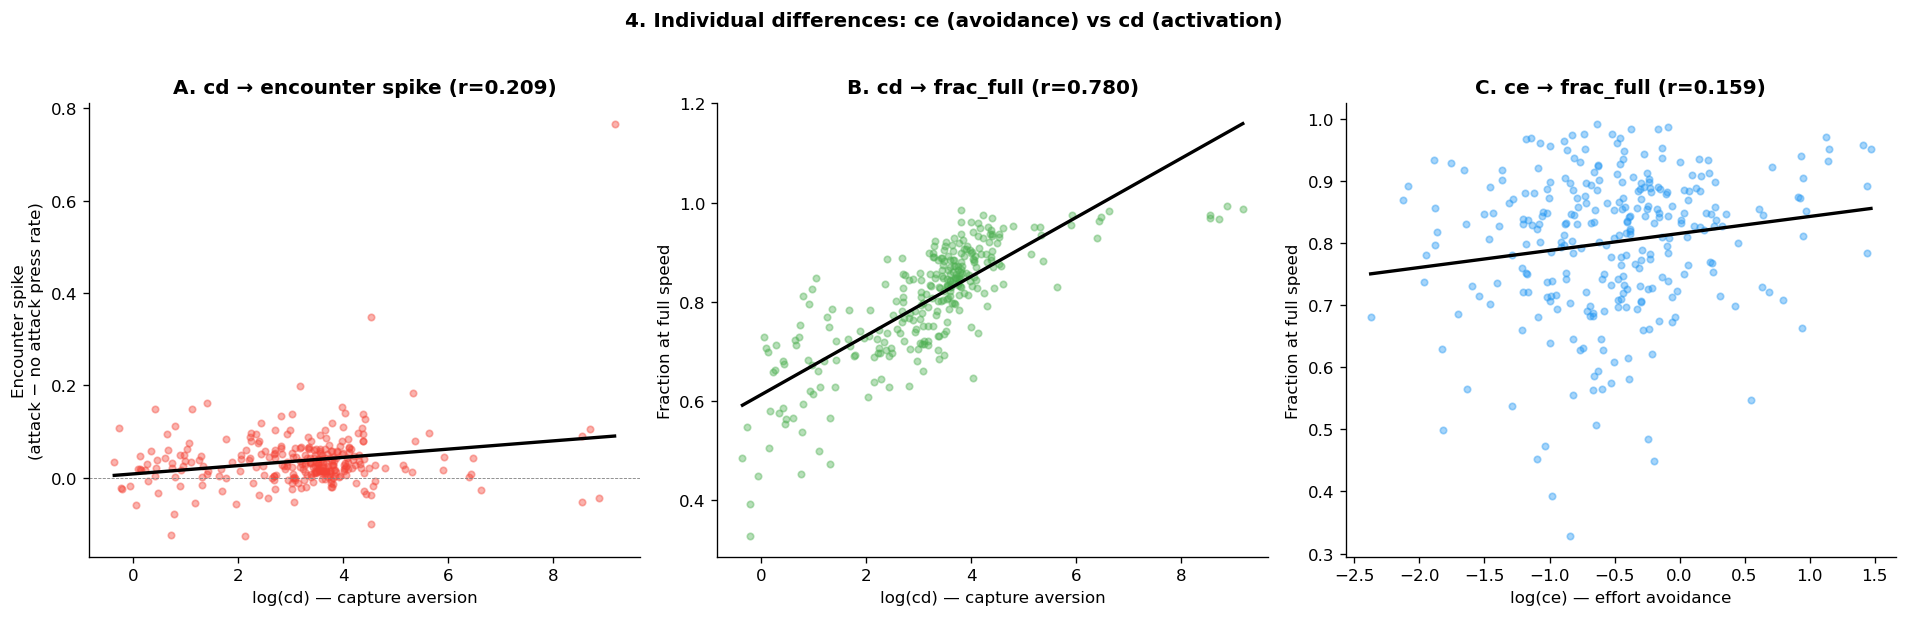


Parameter → vigor correlations:
  cd → encounter spike: r=+0.209, p=0.0003
  cd → frac_full:       r=+0.780, p=0.0000
  ce → encounter spike: r=+0.051
  ce → frac_full:       r=+0.159, p=0.0067


In [6]:
# Load 2+2 params
params_path = RESULTS_DIR / "oc_evc_final_params.csv"
params_22 = pd.read_csv(params_path)
params_22 = params_22[~params_22['subj'].isin(EXCLUDE)]
params_22['log_ce'] = np.log(params_22['c_effort'])
params_22['log_cd'] = np.log(params_22['c_death'])

# Encounter spike per subject (norm_rate, attack - non-attack in reactive epoch)
if vigor_metrics_path.exists():
    sub_atk = metrics[(metrics['epoch']=='reactive')&(metrics['is_attack']==1)].groupby('subj')['norm_rate'].mean()
    sub_noatk = metrics[(metrics['epoch']=='reactive')&(metrics['is_attack']==0)].groupby('subj')['norm_rate'].mean()
    shared = sorted(set(sub_atk.index) & set(sub_noatk.index))
    spike = pd.DataFrame({'subj': shared, 'encounter_spike': (sub_atk.loc[shared] - sub_noatk.loc[shared]).values})

    # Mean frac_full per subject
    subj_ff = metrics[metrics['epoch']=='full'].groupby('subj')['frac_full'].mean().reset_index()

    # Merge
    merged = spike.merge(params_22, on='subj').merge(subj_ff, on='subj')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # A: cd → encounter spike
    ax = axes[0]
    r, p = pearsonr(merged['log_cd'], merged['encounter_spike'])
    ax.scatter(merged['log_cd'], merged['encounter_spike'], s=15, alpha=0.4, color='#F44336')
    m, b = np.polyfit(merged['log_cd'], merged['encounter_spike'], 1)
    x = np.linspace(merged['log_cd'].min(), merged['log_cd'].max(), 100)
    ax.plot(x, m*x+b, 'k-', lw=2)
    ax.set_xlabel('log(cd) — capture aversion')
    ax.set_ylabel('Encounter spike\n(attack − no attack press rate)')
    ax.set_title(f'A. cd → encounter spike (r={r:.3f})', fontweight='bold')
    ax.axhline(0, color='gray', ls='--', lw=0.5)

    # B: cd → frac_full
    ax = axes[1]
    r2, p2 = pearsonr(merged['log_cd'], merged['frac_full'])
    ax.scatter(merged['log_cd'], merged['frac_full'], s=15, alpha=0.4, color='#4CAF50')
    m, b = np.polyfit(merged['log_cd'], merged['frac_full'], 1)
    ax.plot(x, m*x+b, 'k-', lw=2)
    ax.set_xlabel('log(cd) — capture aversion')
    ax.set_ylabel('Fraction at full speed')
    ax.set_title(f'B. cd → frac_full (r={r2:.3f})', fontweight='bold')

    # C: ce → frac_full (expect null)
    ax = axes[2]
    r3, p3 = pearsonr(merged['log_ce'], merged['frac_full'])
    ax.scatter(merged['log_ce'], merged['frac_full'], s=15, alpha=0.4, color='#2196F3')
    m, b = np.polyfit(merged['log_ce'], merged['frac_full'], 1)
    x2 = np.linspace(merged['log_ce'].min(), merged['log_ce'].max(), 100)
    ax.plot(x2, m*x2+b, 'k-', lw=2)
    ax.set_xlabel('log(ce) — effort avoidance')
    ax.set_ylabel('Fraction at full speed')
    ax.set_title(f'C. ce → frac_full (r={r3:.3f})', fontweight='bold')

    plt.suptitle('4. Individual differences: ce (avoidance) vs cd (activation)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\nParameter → vigor correlations:")
    print(f"  cd → encounter spike: r={r:+.3f}, p={p:.4f}")
    print(f"  cd → frac_full:       r={r2:+.3f}, p={p2:.4f}")
    print(f"  ce → encounter spike: r={pearsonr(merged['log_ce'], merged['encounter_spike'])[0]:+.3f}")
    print(f"  ce → frac_full:       r={r3:+.3f}, p={p3:.4f}")
else:
    print("Run vigor pipeline first (scripts/vigor_pipeline/compute_metrics.py)")

## 5. Summary: The full trial in one figure

Three-panel figure showing the entire trial timeline with all cookies combined (cookie-controlled):
- **Pre-encounter:** threat drives anticipatory vigor
- **Encounter:** predator appearance triggers motor spike
- **Terminal:** pressing as predator approaches strike

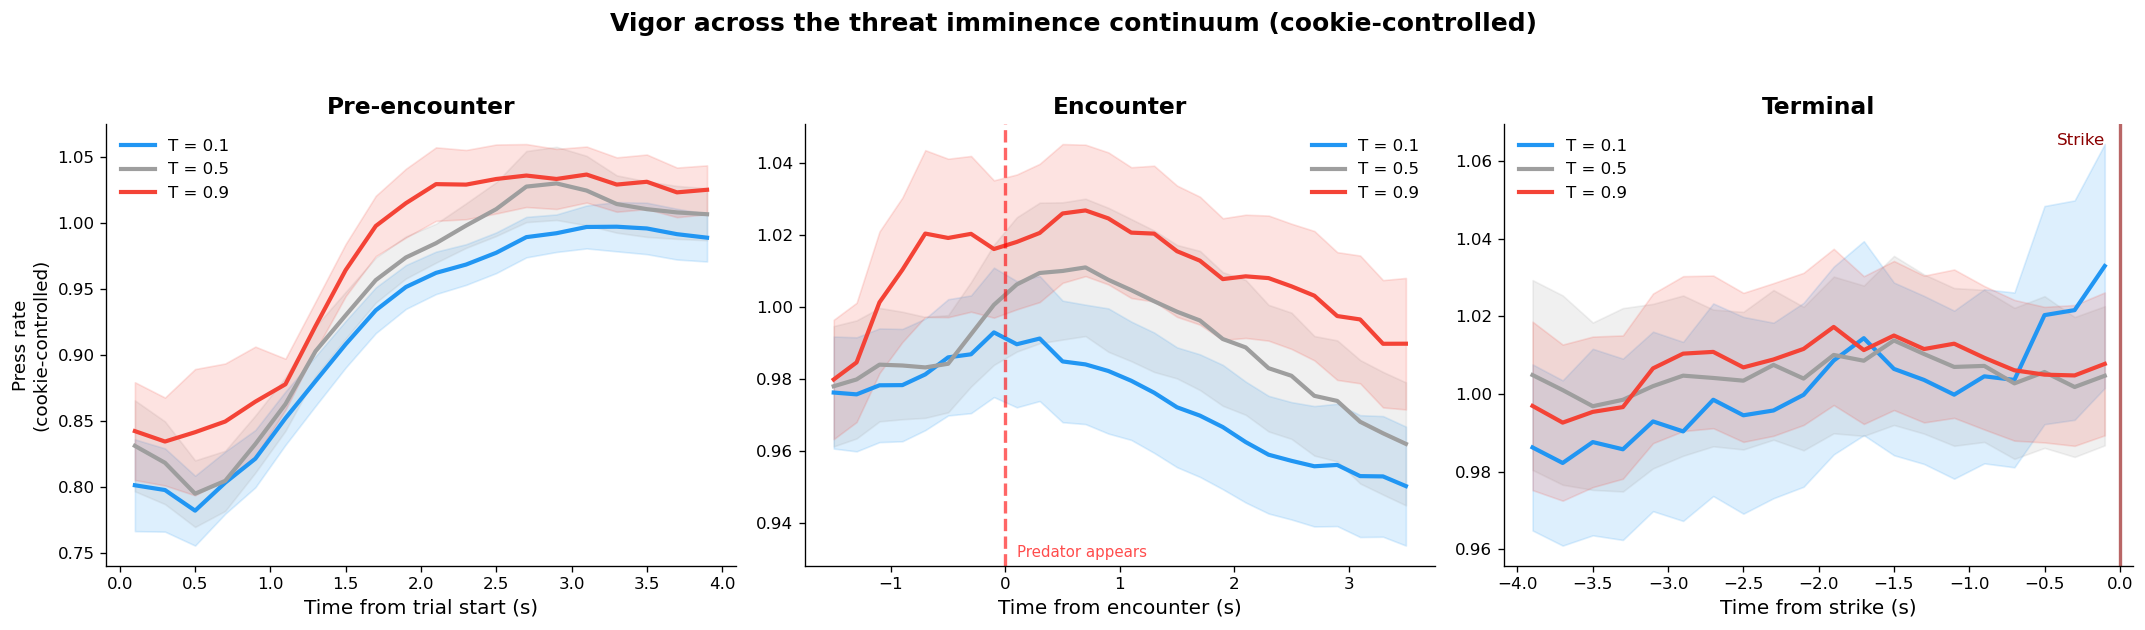

Three phases:
  1. Pre-encounter: Higher threat → higher press rate (anticipatory mobilization)
  2. Encounter: Predator appearance shifts vigor (reactive defense)
  3. Terminal: Final pressing as predator closes in


In [7]:
# Combined figure: onset → encounter → strike, all cookies (cookie-controlled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Onset-aligned (0 to 4s)
ax = axes[0]
ts = agg_timecourse(onset_df, ['T_round'], val_col='rate_cc')
ts = ts[ts['t_bin'] <= 4.0]
for T in [0.1, 0.5, 0.9]:
    d = ts[ts['T_round'] == T].sort_values('t_bin')
    m = smooth(d['mean']); s = smooth(d['sem'])
    ax.plot(d['t_bin'], m, color=C[T], lw=2.5, label=f'T = {T}')
    ax.fill_between(d['t_bin'], m - s, m + s, color=C[T], alpha=0.15)
ax.set_xlabel('Time from trial start (s)', fontsize=12)
ax.set_ylabel('Press rate\n(cookie-controlled)', fontsize=11)
ax.set_title('Pre-encounter', fontweight='bold', fontsize=14)
ax.legend(fontsize=10, frameon=False)

# Panel 2: Encounter-aligned (-1.5 to 3.5s)
ax = axes[1]
ts = agg_timecourse(enc_df, ['T_round'], val_col='rate_cc')
ts = ts[(ts['t_bin'] >= -1.5) & (ts['t_bin'] <= 3.5)]
for T in [0.1, 0.5, 0.9]:
    d = ts[ts['T_round'] == T].sort_values('t_bin')
    m = smooth(d['mean']); s = smooth(d['sem'])
    ax.plot(d['t_bin'], m, color=C[T], lw=2.5, label=f'T = {T}')
    ax.fill_between(d['t_bin'], m - s, m + s, color=C[T], alpha=0.15)
ax.axvline(0, color='red', ls='--', lw=2, alpha=0.6)
ax.set_xlabel('Time from encounter (s)', fontsize=12)
ax.set_title('Encounter', fontweight='bold', fontsize=14)
ax.legend(fontsize=10, frameon=False)
ax.annotate('Predator appears', xy=(0.1, 0.02), xycoords=('data', 'axes fraction'),
            fontsize=9, color='red', alpha=0.7)

# Panel 3: Strike-aligned (-4 to 0s)
ax = axes[2]
ts = agg_timecourse(strike_df, ['T_round'], val_col='rate_cc')
ts = ts[(ts['t_bin'] >= -4) & (ts['t_bin'] <= 0)]
for T in [0.1, 0.5, 0.9]:
    d = ts[ts['T_round'] == T].sort_values('t_bin')
    if len(d) < 3: continue
    m = smooth(d['mean']); s = smooth(d['sem'])
    ax.plot(d['t_bin'], m, color=C[T], lw=2.5, label=f'T = {T}')
    ax.fill_between(d['t_bin'], m - s, m + s, color=C[T], alpha=0.15)
ax.axvline(0, color='darkred', ls='-', lw=2, alpha=0.6)
ax.set_xlabel('Time from strike (s)', fontsize=12)
ax.set_title('Terminal', fontweight='bold', fontsize=14)
ax.legend(fontsize=10, frameon=False)
ax.annotate('Strike', xy=(-0.1, 0.98), xycoords=('data', 'axes fraction'),
            fontsize=10, color='darkred', ha='right', va='top')

plt.suptitle('Vigor across the threat imminence continuum (cookie-controlled)',
             fontweight='bold', fontsize=15, y=1.04)
plt.tight_layout()
plt.show()

print("Three phases:")
print("  1. Pre-encounter: Higher threat → higher press rate (anticipatory mobilization)")
print("  2. Encounter: Predator appearance shifts vigor (reactive defense)")
print("  3. Terminal: Final pressing as predator closes in")